# 数据分布：原理与可视化 — 配套代码



## 全局设置（每次使用前必须首先运行此单元格）

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
mpl.set_loglevel("error")  # 只显示错误，不显示警告

# ── 图片中支持中文字体 ──────────────────────────────────────────────
#plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["font.family"] = "SimHei"  # 只留 Windows 自带黑体，无任何警告
plt.rcParams["axes.unicode_minus"] = False

# ── 全局样式 ──────────────────────────────────────────────
plt.rcParams['figure.dpi']        = 120
plt.rcParams['savefig.dpi']       = 300
plt.rcParams['font.size']         = 11
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

np.random.seed(42)
print('✅ 全局设置完成')

✅ 全局设置完成


---
<a id='sec1'></a>
## 均值相同，分布不同：可视化的必要性

三组数据均值和标准差完全相同，但分布形态截然不同。

── 三组数据的基本统计量 ──
A：正态分布        均值=0.019  标准差=0.979  偏度=0.12  峰态=0.07
B：双峰分布        均值=0.035  标准差=1.563  偏度=-0.01  峰态=-1.62
C：右偏分布        均值=0.000  标准差=1.000  偏度=1.88  峰态=4.74


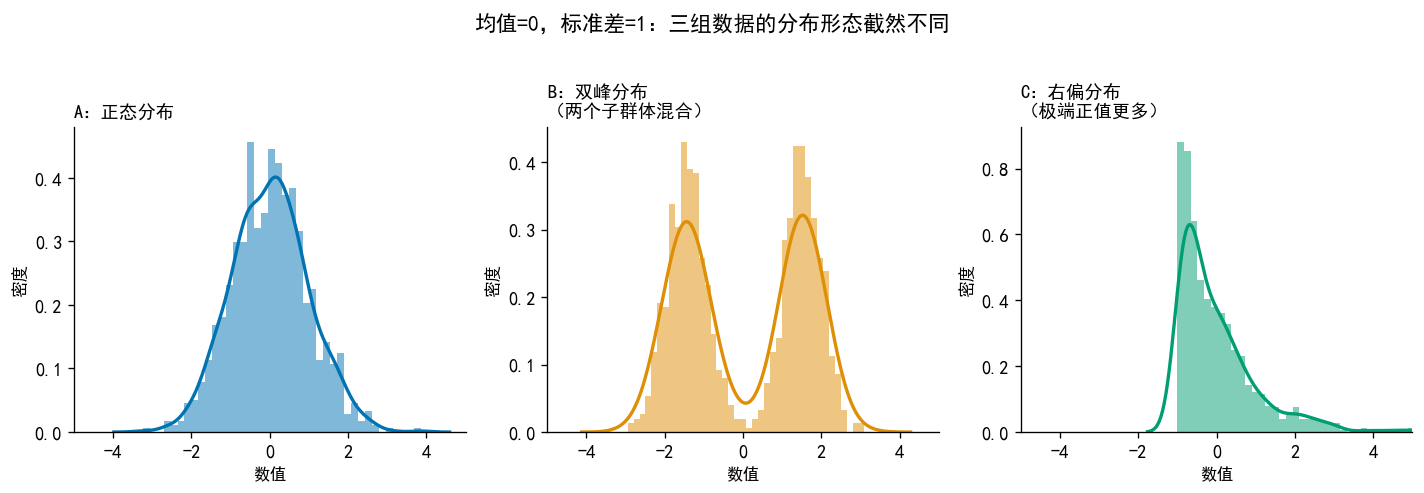

In [8]:
np.random.seed(42)
N = 1000

# 三组数据：均值=0, 标准差≈1，但形态不同
data_A = np.random.normal(0, 1, N)                          # 正态分布
data_B = np.concatenate([                                    # 双峰分布
    np.random.normal(-1.5, 0.5, N//2),
    np.random.normal(1.5, 0.5, N//2)
])
data_C = np.random.exponential(1, N)                         # 右偏分布
data_C = (data_C - data_C.mean()) / data_C.std()            # 标准化

datasets = {'A：正态分布': data_A,
            'B：双峰分布\n（两个子群体混合）': data_B,
            'C：右偏分布\n（极端正值更多）': data_C}

# 打印统计量验证
print('── 三组数据的基本统计量 ──')
for name, d in datasets.items():
    label = name.split('\n')[0]
    print(f'{label:12s}  均值={d.mean():.3f}  标准差={d.std():.3f}  '
          f'偏度={stats.skew(d):.2f}  峰态={stats.kurtosis(d):.2f}')

# ── 绘图 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = sns.color_palette('colorblind', 3)

for ax, (title, data), color in zip(axes, datasets.items(), colors):
    ax.hist(data, bins=40, density=True, alpha=0.5,
            color=color, edgecolor='none')
    sns.kdeplot(data, ax=ax, color=color, linewidth=2)
    ax.set_title(title, fontsize=11, fontweight='bold', loc='left')
    ax.set_xlabel('数值', fontsize=10)
    ax.set_ylabel('密度', fontsize=10)
    ax.set_xlim(-5, 5)
    sns.despine(ax=ax)

plt.suptitle('均值=0，标准差=1：三组数据的分布形态截然不同',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
<a id='sec2-1'></a>
## 频数、频率、密度三种直方图对比

同一组数据，三种纵轴的含义与适用场景。

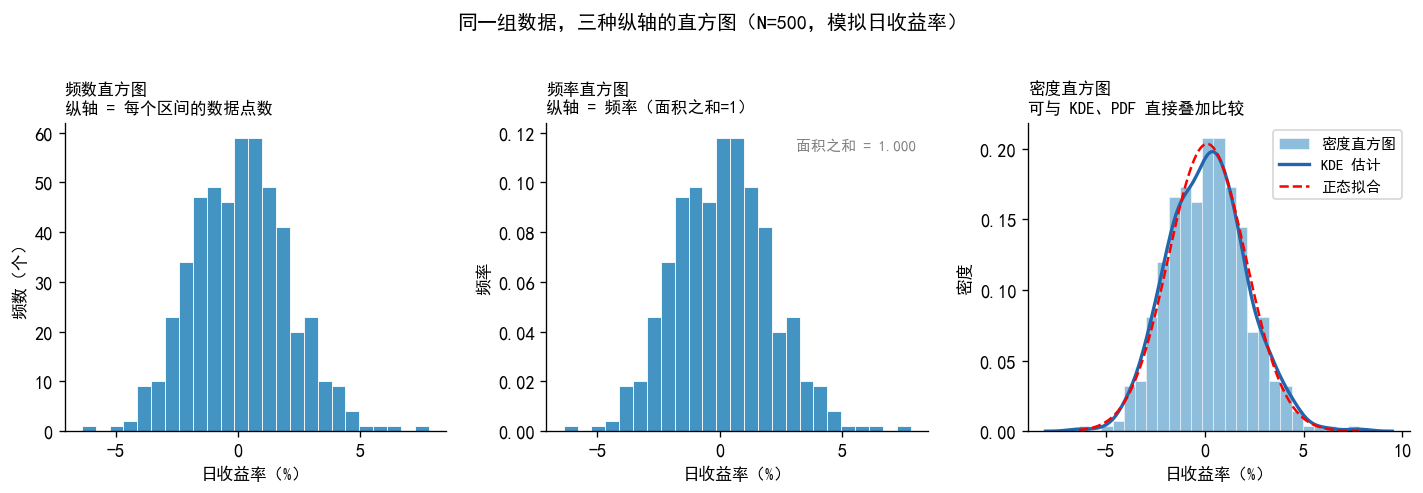

💡 关键：只有密度直方图（density=True）才能与 KDE 曲线叠加在同一坐标系比较。


In [9]:
np.random.seed(42)
N = 500
# 模拟日收益率（%）
returns = np.random.normal(0.1, 2.0, N)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
bins = 25
color = '#4393c3'

# ── 子图1：频数 ───────────────────────────────────────────
axes[0].hist(returns, bins=bins, color=color, edgecolor='white', linewidth=0.5)
axes[0].set_title('频数直方图\n纵轴 = 每个区间的数据点数', fontsize=10,
                  fontweight='bold', loc='left')
axes[0].set_ylabel('频数（个）', fontsize=10)
axes[0].set_xlabel('日收益率（%）', fontsize=10)
sns.despine(ax=axes[0])

# ── 子图2：频率 ───────────────────────────────────────────
counts, edges = np.histogram(returns, bins=bins)
freq = counts / counts.sum()
width = edges[1] - edges[0]
axes[1].bar(edges[:-1], freq, width=width, color=color,
            edgecolor='white', linewidth=0.5, align='edge')
axes[1].set_title('频率直方图\n纵轴 = 频率（面积之和=1）', fontsize=10,
                  fontweight='bold', loc='left')
axes[1].set_ylabel('频率', fontsize=10)
axes[1].set_xlabel('日收益率（%）', fontsize=10)
axes[1].text(0.97, 0.95, f'面积之和 = {freq.sum():.3f}',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=9, color='gray')
sns.despine(ax=axes[1])

# ── 子图3：密度 + KDE + 理论正态曲线 ─────────────────────
axes[2].hist(returns, bins=bins, density=True, color=color,
             edgecolor='white', linewidth=0.5, alpha=0.6, label='密度直方图')
sns.kdeplot(returns, ax=axes[2], color='#2166ac',
            linewidth=2, label='KDE 估计')
# 叠加理论正态曲线
x_range = np.linspace(returns.min(), returns.max(), 200)
axes[2].plot(x_range,
             stats.norm.pdf(x_range, returns.mean(), returns.std()),
             'r--', linewidth=1.5, label='正态拟合')
axes[2].set_title('密度直方图\n可与 KDE、PDF 直接叠加比较', fontsize=10,
                  fontweight='bold', loc='left')
axes[2].set_ylabel('密度', fontsize=10)
axes[2].set_xlabel('日收益率（%）', fontsize=10)
axes[2].legend(fontsize=9)
sns.despine(ax=axes[2])

plt.suptitle('同一组数据，三种纵轴的直方图（N=500，模拟日收益率）',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('💡 关键：只有密度直方图（density=True）才能与 KDE 曲线叠加在同一坐标系比较。')

---
<a id='sec2-2'></a>
## Bin 宽度选择的影响



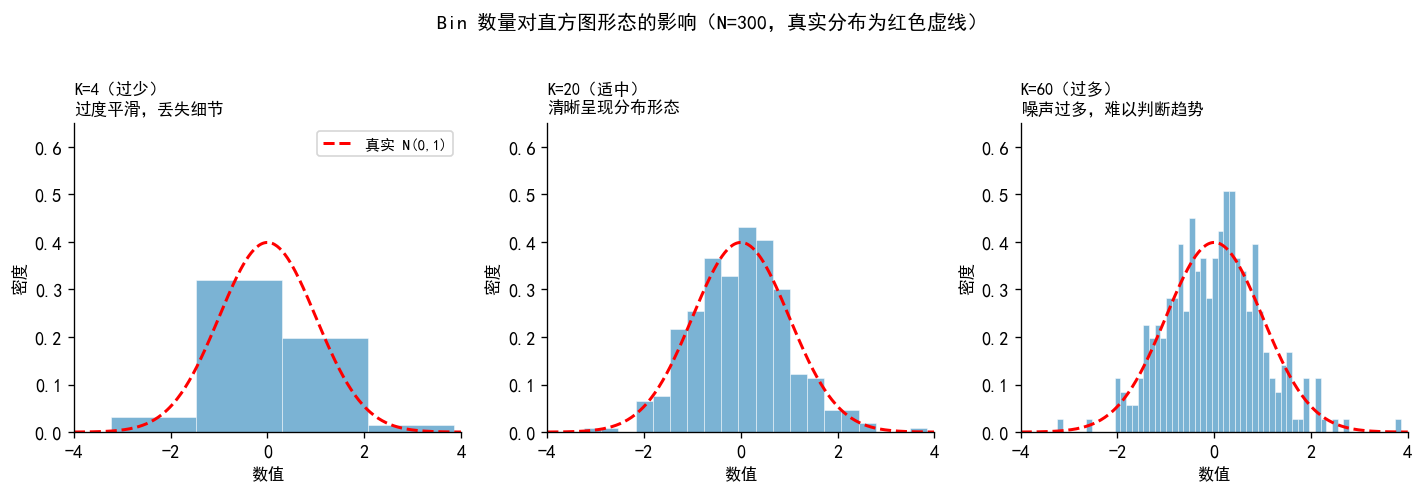

In [10]:
np.random.seed(42)
N = 300
data = np.random.normal(0, 1, N)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
K_values = [4, 20, 60]
labels   = ['K=4（过少）\n过度平滑，丢失细节',
             'K=20（适中）\n清晰呈现分布形态',
             'K=60（过多）\n噪声过多，难以判断趋势']

# 真实正态密度曲线
x_range = np.linspace(-4, 4, 300)
pdf_true = stats.norm.pdf(x_range)

for ax, K, label in zip(axes, K_values, labels):
    ax.hist(data, bins=K, density=True, color='#4393c3',
            edgecolor='white', linewidth=0.4, alpha=0.7)
    ax.plot(x_range, pdf_true, 'r--', linewidth=1.8,
            label='真实 N(0,1)')
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 0.65)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('数值', fontsize=10)
    ax.set_ylabel('密度', fontsize=10)
    sns.despine(ax=ax)

axes[0].legend(fontsize=9)
plt.suptitle('Bin 数量对直方图形态的影响（N=300，真实分布为红色虚线）',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
<a id='sec2-3'></a>
## 三种 Bin 自动选择规则对比



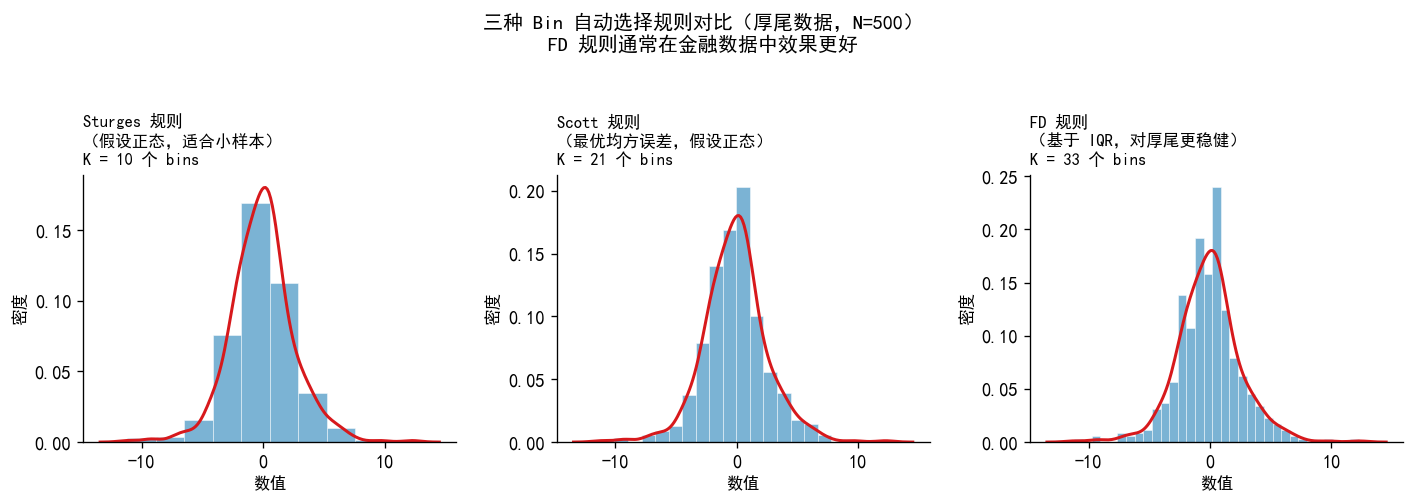

sturges   : K =  10 bins, h = 2.343
scott     : K =  21 bins, h = 1.116
fd        : K =  33 bins, h = 0.710


In [11]:
np.random.seed(42)
N = 500
# 厚尾数据（模拟金融收益率）
data = stats.t.rvs(df=4, size=N) * 2

rules   = ['sturges', 'scott', 'fd']
titles  = ['Sturges 规则\n（假设正态，适合小样本）',
           'Scott 规则\n（最优均方误差，假设正态）',
           'FD 规则\n（基于 IQR，对厚尾更稳健）']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, rule, title in zip(axes, rules, titles):
    counts, edges, _ = ax.hist(data, bins=rule, density=True,
                               color='#4393c3', edgecolor='white',
                               linewidth=0.4, alpha=0.7)
    sns.kdeplot(data, ax=ax, color='#d7191c', linewidth=1.8)
    n_bins = len(edges) - 1
    ax.set_title(f'{title}\nK = {n_bins} 个 bins',
                 fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('数值', fontsize=10)
    ax.set_ylabel('密度', fontsize=10)
    sns.despine(ax=ax)

plt.suptitle('三种 Bin 自动选择规则对比（厚尾数据，N=500）\n'
             'FD 规则通常在金融数据中效果更好',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# 打印各规则的 bin 数
for rule in rules:
    _, edges = np.histogram(data, bins=rule)
    print(f'{rule:10s}: K = {len(edges)-1:3d} bins, h = {edges[1]-edges[0]:.3f}')

---
<a id='sec3-1'></a>
## KDE：带宽选择的影响



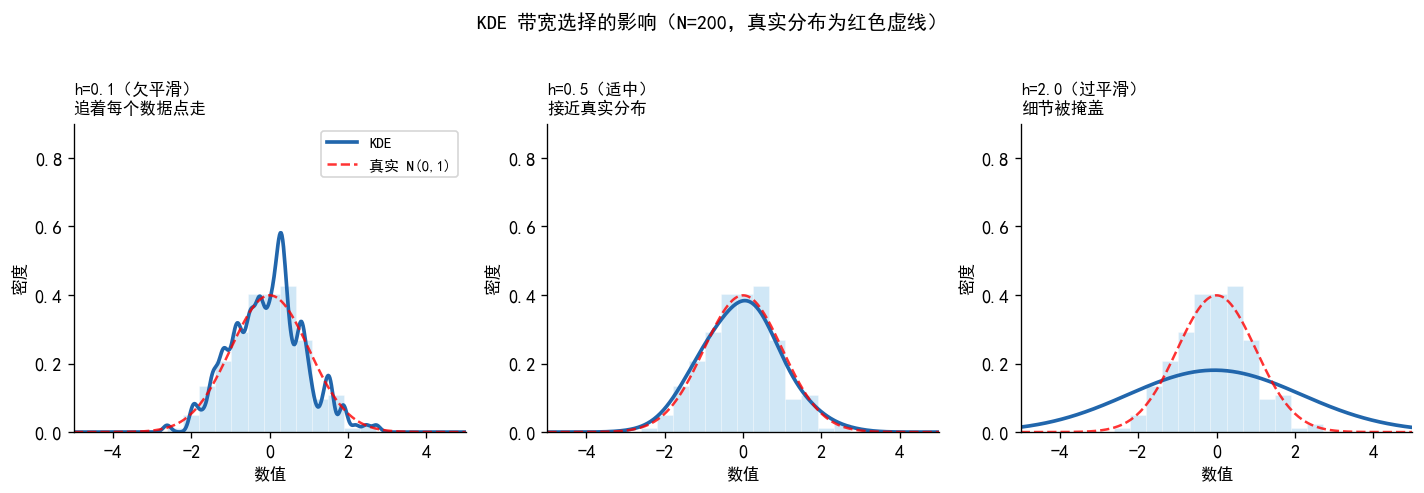

In [12]:
np.random.seed(42)
N = 200
data = np.random.normal(0, 1, N)
x_range = np.linspace(-5, 5, 500)
pdf_true = stats.norm.pdf(x_range)

bandwidths = [0.1, 0.5, 2.0]
bw_labels  = ['h=0.1（欠平滑）\n追着每个数据点走',
              'h=0.5（适中）\n接近真实分布',
              'h=2.0（过平滑）\n细节被掩盖']

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, h, label in zip(axes, bandwidths, bw_labels):
    # 密度直方图（背景）
    ax.hist(data, bins='fd', density=True, color='#b2d8f0',
            edgecolor='white', linewidth=0.3, alpha=0.6)
    # KDE 曲线（指定带宽）
    kde = stats.gaussian_kde(data, bw_method=h / data.std())
    ax.plot(x_range, kde(x_range), color='#2166ac', linewidth=2.2,
            label='KDE')
    # 真实密度曲线（参考）
    ax.plot(x_range, pdf_true, 'r--', linewidth=1.5, alpha=0.8,
            label='真实 N(0,1)')
    ax.set_xlim(-5, 5)
    ax.set_ylim(0, 0.9)
    ax.set_title(label, fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('数值', fontsize=10)
    ax.set_ylabel('密度', fontsize=10)
    sns.despine(ax=ax)

axes[0].legend(fontsize=9)
plt.suptitle('KDE 带宽选择的影响（N=200，真实分布为红色虚线）',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
<a id='sec3-2'></a>
## KDE vs 直方图：密度叠加图

展示直方图与 KDE 的互补关系——直方图"离散"，KDE"平滑"。

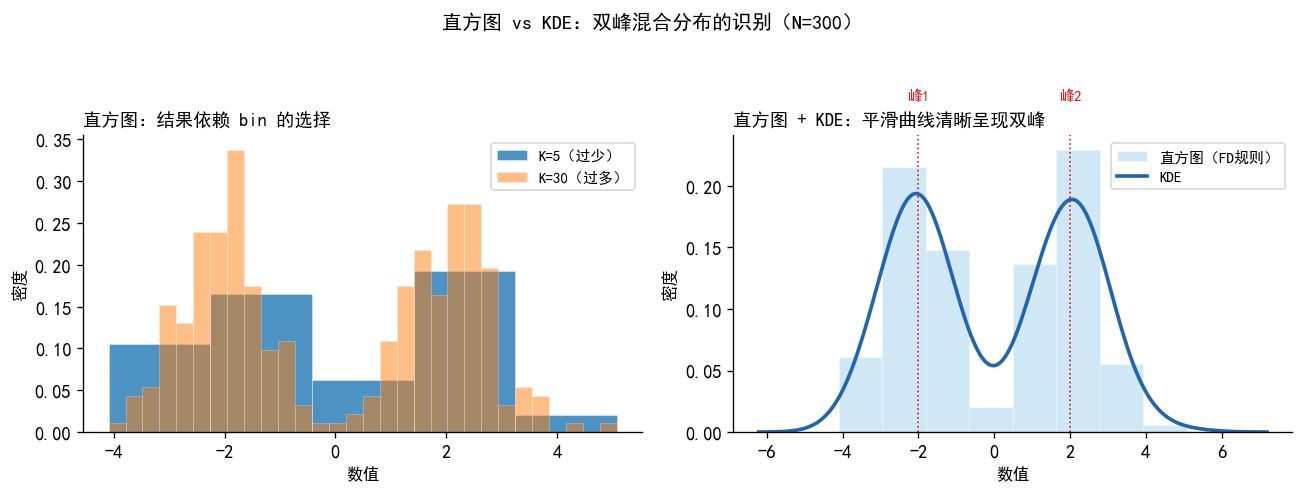

In [13]:
np.random.seed(42)
N = 300
# 混合分布（双峰）
data = np.concatenate([
    np.random.normal(-2, 0.8, N//2),
    np.random.normal(2, 0.8, N//2)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# ── 左图：只有直方图 ──────────────────────────────────────
for K, alpha, label in [(5, 0.8, 'K=5（过少）'), (30, 0.5, 'K=30（过多）')]:
    axes[0].hist(data, bins=K, density=True, alpha=alpha, label=label,
                 edgecolor='white', linewidth=0.3)
axes[0].set_title('直方图：结果依赖 bin 的选择',
                  fontsize=11, fontweight='bold', loc='left')
axes[0].set_xlabel('数值', fontsize=10)
axes[0].set_ylabel('密度', fontsize=10)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

# ── 右图：直方图 + KDE，展示双峰 ─────────────────────────
axes[1].hist(data, bins='fd', density=True, color='#b2d8f0',
             edgecolor='white', linewidth=0.3, alpha=0.6, label='直方图（FD规则）')
sns.kdeplot(data, ax=axes[1], color='#2166ac', linewidth=2.2, label='KDE')
# 标注两个峰
for peak, txt in [(-2, '峰1'), (2, '峰2')]:
    axes[1].axvline(peak, color='#d7191c', linewidth=1, linestyle=':')
    axes[1].text(peak, 0.27, txt, ha='center', fontsize=9, color='#d7191c')
axes[1].set_title('直方图 + KDE：平滑曲线清晰呈现双峰',
                  fontsize=11, fontweight='bold', loc='left')
axes[1].set_xlabel('数值', fontsize=10)
axes[1].set_ylabel('密度', fontsize=10)
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.suptitle('直方图 vs KDE：双峰混合分布的识别（N=300）',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
<a id='sec4-1'></a>
## 箱线图的构造与 IQR 规则



Q1 = -0.700,  Q2（中位数）= 0.013,  Q3 = 0.637
IQR = 1.337
下须 = Q1 - 1.5×IQR = -2.706
上须 = Q3 + 1.5×IQR = 2.642
离群值数量: 4  （占比 0.8%）
理论预期（正态分布）: 约 3.5 个（0.7%）


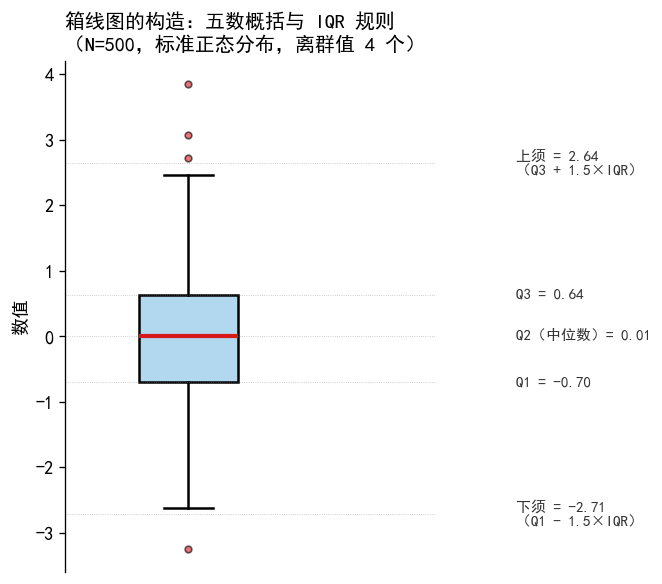

In [14]:
np.random.seed(42)
N = 500
data = np.random.normal(0, 1, N)

q1, q2, q3 = np.percentile(data, [25, 50, 75])
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
outliers = data[(data < lower_fence) | (data > upper_fence)]

print(f'Q1 = {q1:.3f},  Q2（中位数）= {q2:.3f},  Q3 = {q3:.3f}')
print(f'IQR = {iqr:.3f}')
print(f'下须 = Q1 - 1.5×IQR = {lower_fence:.3f}')
print(f'上须 = Q3 + 1.5×IQR = {upper_fence:.3f}')
print(f'离群值数量: {len(outliers)}  （占比 {len(outliers)/N*100:.1f}%）')
print(f'理论预期（正态分布）: 约 {N*0.007:.1f} 个（0.7%）')

# ── 带标注的箱线图 ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 5))

bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#b2d8f0', linewidth=1.5),
                medianprops=dict(color='#d7191c', linewidth=2.5),
                whiskerprops=dict(linewidth=1.5),
                capprops=dict(linewidth=1.5),
                flierprops=dict(marker='o', markersize=4,
                                markerfacecolor='#d7191c', alpha=0.6))

# 标注关键统计量
annotations = [
    (q1,           f'Q1 = {q1:.2f}'),
    (q2,           f'Q2（中位数）= {q2:.2f}'),
    (q3,           f'Q3 = {q3:.2f}'),
    (upper_fence,  f'上须 = {upper_fence:.2f}\n（Q3 + 1.5×IQR）'),
    (lower_fence,  f'下须 = {lower_fence:.2f}\n（Q1 - 1.5×IQR）'),
]
for val, label in annotations:
    ax.annotate(label,
                xy=(1.22, val), xycoords=('axes fraction', 'data'),
                fontsize=9, va='center', color='#333333')
    ax.axhline(val, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

ax.set_xticks([])
ax.set_ylabel('数值', fontsize=11)
ax.set_title('箱线图的构造：五数概括与 IQR 规则\n'
             f'（N={N}，标准正态分布，离群值 {len(outliers)} 个）',
             fontsize=12, fontweight='bold', loc='left')
ax.set_xlim(0.5, 2.0)  # 为标注留出空间
sns.despine(ax=ax, bottom=True)

plt.tight_layout()
plt.show()

---
<a id='sec4-2'></a>
## 箱线图 vs 小提琴图：双峰分布的识别



── 两组统计量对比 ──
组A（正态）: 均值=0.007, 标准差=0.980, 中位数=0.013
组B（双峰）: 均值=0.016, 标准差=1.624, 中位数=0.037


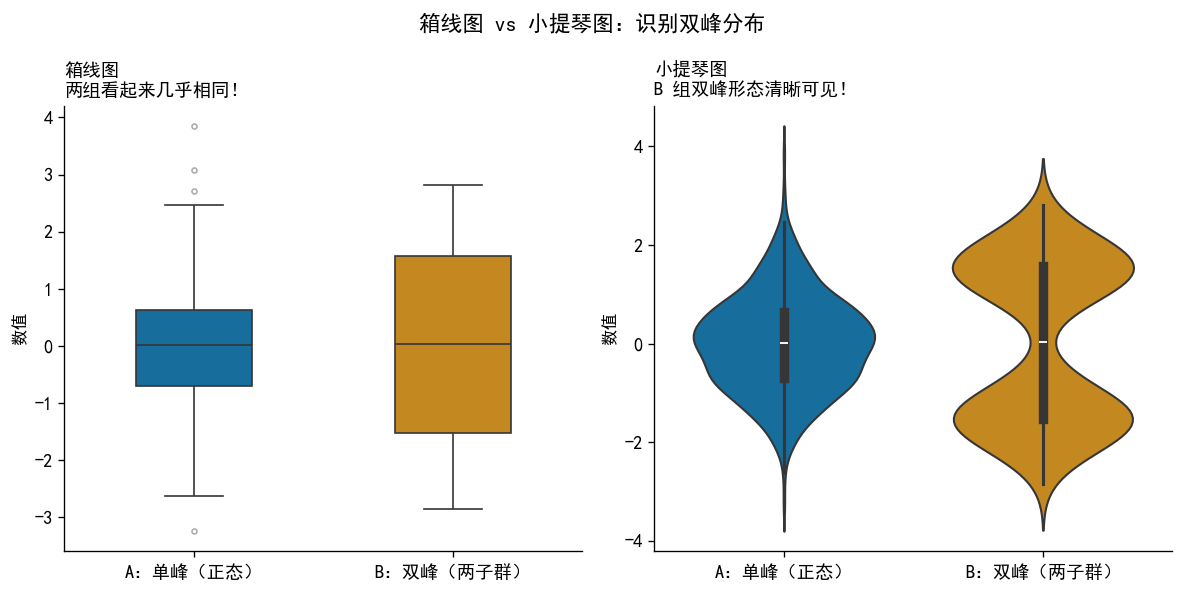

In [15]:
np.random.seed(42)
N = 500

# 两组数据：均值和标准差相近，但形态不同
group_A = np.random.normal(0, 1, N)               # 单峰
group_B = np.concatenate([                         # 双峰
    np.random.normal(-1.5, 0.5, N//2),
    np.random.normal(1.5, 0.5, N//2)
])

df = pd.DataFrame({
    '数值': np.concatenate([group_A, group_B]),
    '组别': ['A：单峰（正态）'] * N + ['B：双峰（两子群）'] * N
})

print('── 两组统计量对比 ──')
for grp, data in [('A（正态）', group_A), ('B（双峰）', group_B)]:
    print(f'组{grp}: 均值={data.mean():.3f}, 标准差={data.std():.3f}, '
          f'中位数={np.median(data):.3f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
palette = sns.color_palette('colorblind', 2)

# ── 左图：箱线图 ─────────────────────────────────────────
sns.boxplot(data=df, x='组别', y='数值', palette=palette,
            width=0.45, ax=ax1,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax1.set_title('箱线图\n两组看起来几乎相同！', fontsize=11,
              fontweight='bold', loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('数值', fontsize=10)
sns.despine(ax=ax1)

# ── 右图：小提琴图 ────────────────────────────────────────
sns.violinplot(data=df, x='组别', y='数值', palette=palette,
               inner='box', width=0.7, ax=ax2)
ax2.set_title('小提琴图\nB 组双峰形态清晰可见！', fontsize=11,
              fontweight='bold', loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('数值', fontsize=10)
sns.despine(ax=ax2)

plt.suptitle('箱线图 vs 小提琴图：识别双峰分布',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='sec4-3'></a>
## 四种分布形态：综合诊断图

对应讲义中"模拟四个序列"的完整版本：直方图 + KDE + 箱线图 + 小提琴图。

分布                 均值      标准差       偏度     超额峰态
正态分布           -0.006    0.983    0.174    0.567
右偏分布            0.340    1.350    1.516    2.340
左偏分布           -0.307    1.267   -1.238    1.982
厚尾分布            0.200    1.932    0.536    2.931


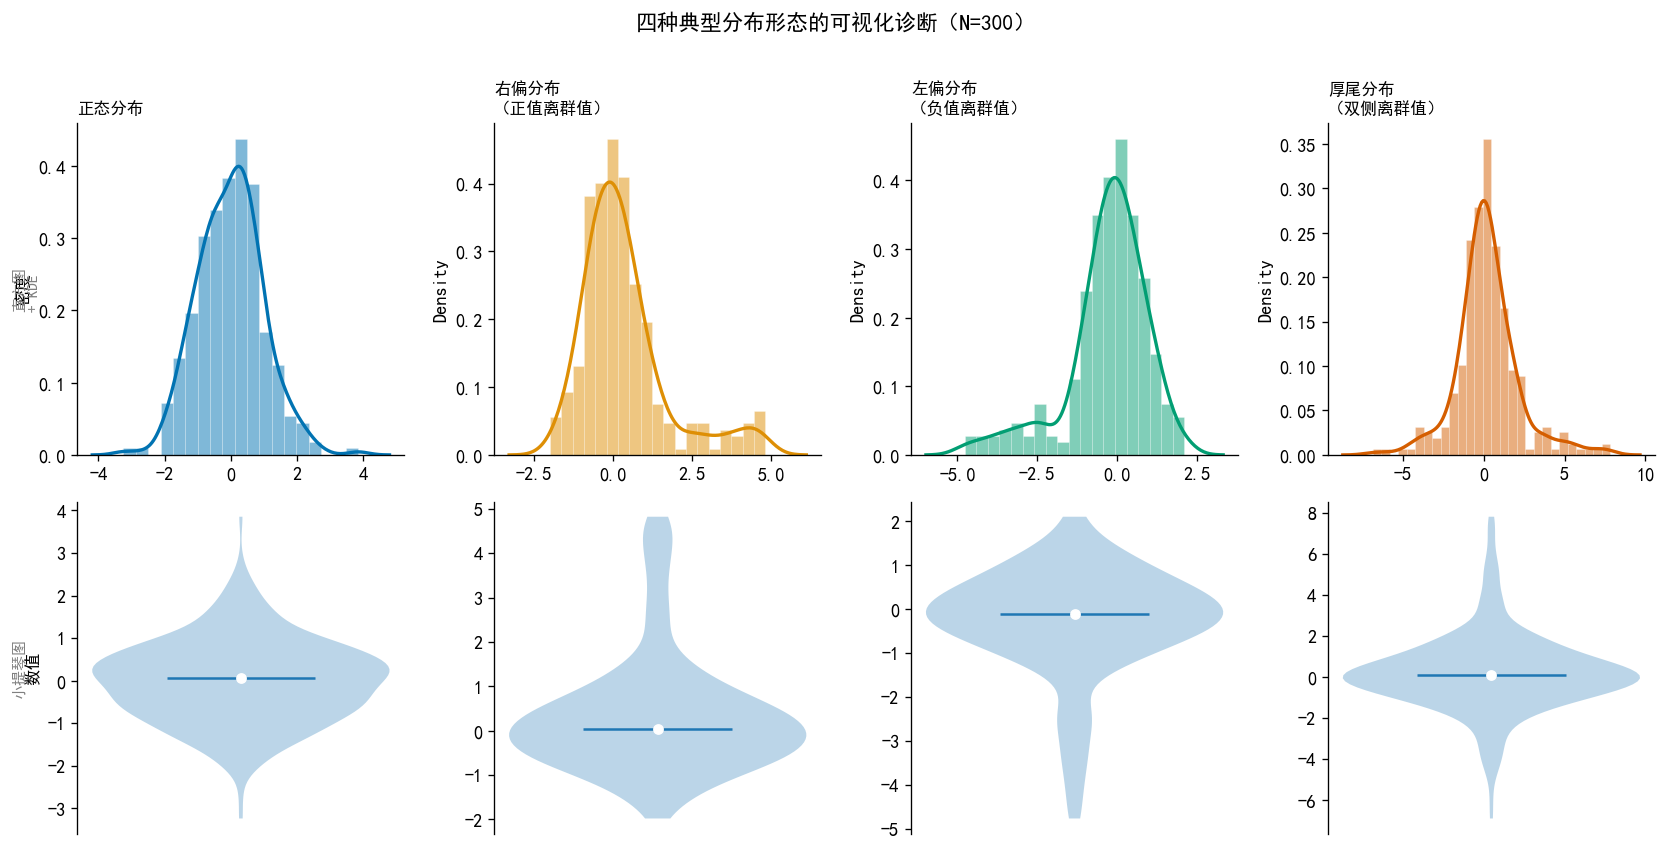

In [16]:
np.random.seed(42)
N = 300

# 四种分布
dist_names = ['正态分布', '右偏分布\n（正值离群值）', '左偏分布\n（负值离群值）', '厚尾分布\n（双侧离群值）']
x1 = np.random.normal(0, 1, N)
x2 = np.concatenate([np.random.normal(0, 0.8, int(N*0.9)),
                      np.random.uniform(2, 5, int(N*0.1))])    # 右偏
x3 = np.concatenate([np.random.normal(0, 0.8, int(N*0.9)),
                      np.random.uniform(-5, -2, int(N*0.1))])  # 左偏
x4 = stats.t.rvs(df=2, size=N)                                 # 厚尾

datasets = [x1, x2, x3, x4]

# 打印描述统计
print(f'{"分布":12s} {"均值":>8s} {"标准差":>8s} {"偏度":>8s} {"超额峰态":>8s}')
for name, d in zip(dist_names, datasets):
    label = name.split('\n')[0]
    print(f'{label:12s} {d.mean():8.3f} {d.std():8.3f} '
          f'{stats.skew(d):8.3f} {stats.kurtosis(d):8.3f}')

# ── 绘图：2行4列 ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
colors = sns.color_palette('colorblind', 4)

for col, (name, data, color) in enumerate(zip(dist_names, datasets, colors)):
    # 上行：直方图 + KDE
    ax_top = axes[0, col]
    ax_top.hist(data, bins='fd', density=True, color=color,
                alpha=0.5, edgecolor='white', linewidth=0.3)
    sns.kdeplot(data, ax=ax_top, color=color, linewidth=2)
    ax_top.set_title(name, fontsize=10, fontweight='bold', loc='left')
    ax_top.set_xlabel('')
    if col == 0:
        ax_top.set_ylabel('密度', fontsize=10)
    sns.despine(ax=ax_top)

    # 下行：小提琴图
    ax_bot = axes[1, col]
    ax_bot.violinplot(data, positions=[0], showmedians=True,
                     showextrema=False)
    ax_bot.set_xticks([])
    # 叠加箱线图核心统计量
    q1, q2, q3 = np.percentile(data, [25, 50, 75])
    ax_bot.scatter([0], [q2], color='white', s=30, zorder=3)
    if col == 0:
        ax_bot.set_ylabel('数值', fontsize=10)
    sns.despine(ax=ax_bot, bottom=True)

axes[0, 0].text(-0.2, 0.5, '直方图\n+ KDE', transform=axes[0,0].transAxes,
                rotation=90, va='center', fontsize=9, color='gray')
axes[1, 0].text(-0.2, 0.5, '小提琴图', transform=axes[1,0].transAxes,
                rotation=90, va='center', fontsize=9, color='gray')

plt.suptitle('四种典型分布形态的可视化诊断（N=300）',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='sec5-1'></a>
## 偏态与峰态的可视化



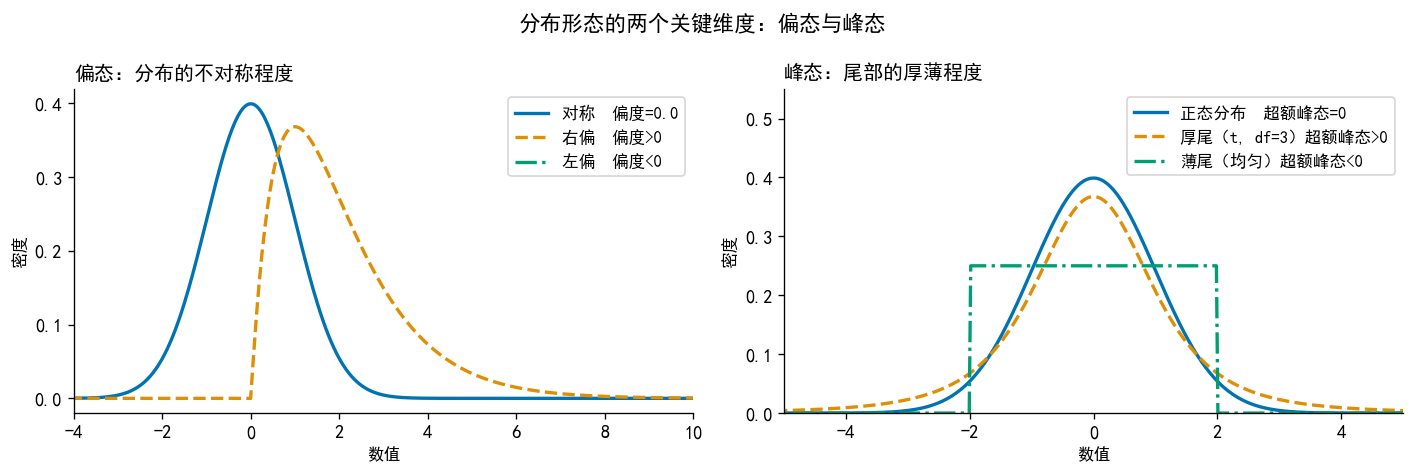

In [17]:
np.random.seed(42)
N = 2000
x_range = np.linspace(-6, 10, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── 左图：偏态对比 ────────────────────────────────────────
ax = axes[0]
palette = sns.color_palette('colorblind', 3)

for dist, label, color, ls in [
    (stats.norm(0, 1),         '对称  偏度=0.0',   palette[0], '-'),
    (stats.gamma(2, scale=1),  '右偏  偏度>0',     palette[1], '--'),
    (stats.gamma(2, scale=-1, loc=6), '左偏  偏度<0', palette[2], '-.')
]:
    ax.plot(x_range, dist.pdf(x_range), color=color,
            linewidth=2, linestyle=ls, label=label)

ax.set_title('偏态：分布的不对称程度', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('数值', fontsize=10)
ax.set_ylabel('密度', fontsize=10)
ax.legend(fontsize=10)
ax.set_xlim(-4, 10)
sns.despine(ax=ax)

# ── 右图：峰态对比 ────────────────────────────────────────
ax = axes[1]
x2 = np.linspace(-6, 6, 500)

for dist, label, color, ls in [
    (stats.norm(0, 1),   '正态分布  超额峰态=0',     palette[0], '-'),
    (stats.t(df=3),      '厚尾（t, df=3）超额峰态>0', palette[1], '--'),
    (stats.uniform(-2,4),'薄尾（均匀）超额峰态<0',   palette[2], '-.')
]:
    ax.plot(x2, dist.pdf(x2), color=color,
            linewidth=2, linestyle=ls, label=label)

ax.set_title('峰态：尾部的厚薄程度', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('数值', fontsize=10)
ax.set_ylabel('密度', fontsize=10)
ax.legend(fontsize=10)
ax.set_xlim(-5, 5)
ax.set_ylim(0, 0.55)
sns.despine(ax=ax)

plt.suptitle('分布形态的两个关键维度：偏态与峰态',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
<a id='sec5-2'></a>
## QQ 图：四种分布对比



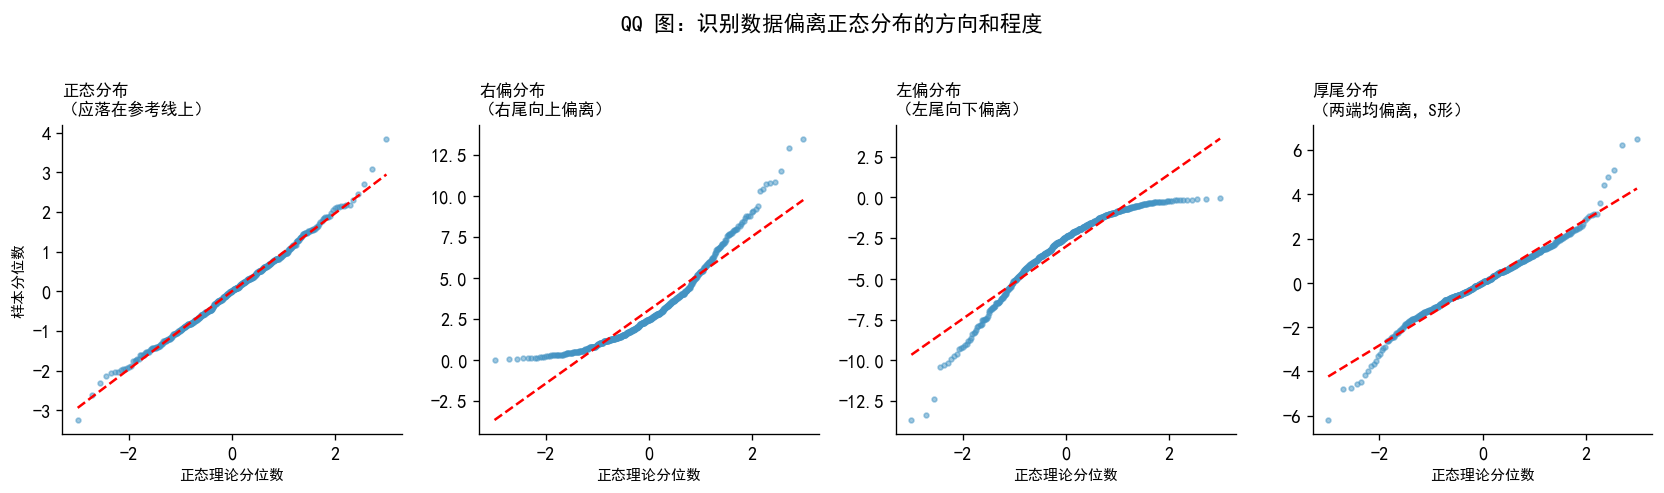

In [18]:
np.random.seed(42)
N = 500

samples = {
    '正态分布\n（应落在参考线上）':    np.random.normal(0, 1, N),
    '右偏分布\n（右尾向上偏离）':       stats.chi2.rvs(df=3, size=N),
    '左偏分布\n（左尾向下偏离）':      -stats.chi2.rvs(df=3, size=N),
    '厚尾分布\n（两端均偏离，S形）':    stats.t.rvs(df=3, size=N),
}

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (title, data) in zip(axes, samples.items()):
    # scipy.stats.probplot 返回 (理论分位数, 样本分位数)
    (theoretical, sample), fit = stats.probplot(data, dist='norm')
    ax.scatter(theoretical, sample, color='#4393c3',
               s=8, alpha=0.5, zorder=2)
    # 参考线
    slope, intercept = fit[0], fit[1]
    x_line = np.array([theoretical.min(), theoretical.max()])
    ax.plot(x_line, slope * x_line + intercept,
            'r--', linewidth=1.5, zorder=3)
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
    ax.set_xlabel('正态理论分位数', fontsize=9)
    if ax == axes[0]:
        ax.set_ylabel('样本分位数', fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('QQ 图：识别数据偏离正态分布的方向和程度',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
<a id='sec6'></a>
## 多组分布比较：宏观经济数据金融案例

使用 `statsmodels` 自带的美国宏观数据，比较不同年代 GDP 增速的分布。

数据：1960–2009 年，共 199 个季度

── 各年代 GDP 增速（%）描述统计 ──
           均值    标准差     偏度    最小值    最大值
decade                                   
1960s   1.064  0.876 -0.375 -1.291  2.426
1970s   0.808  1.097  0.378 -1.224  3.859
1980s   0.748  0.974 -1.005 -2.071  2.223
1990s   0.817  0.547 -0.830 -0.880  1.780
2000s   0.423  0.683 -0.902 -1.661  1.932


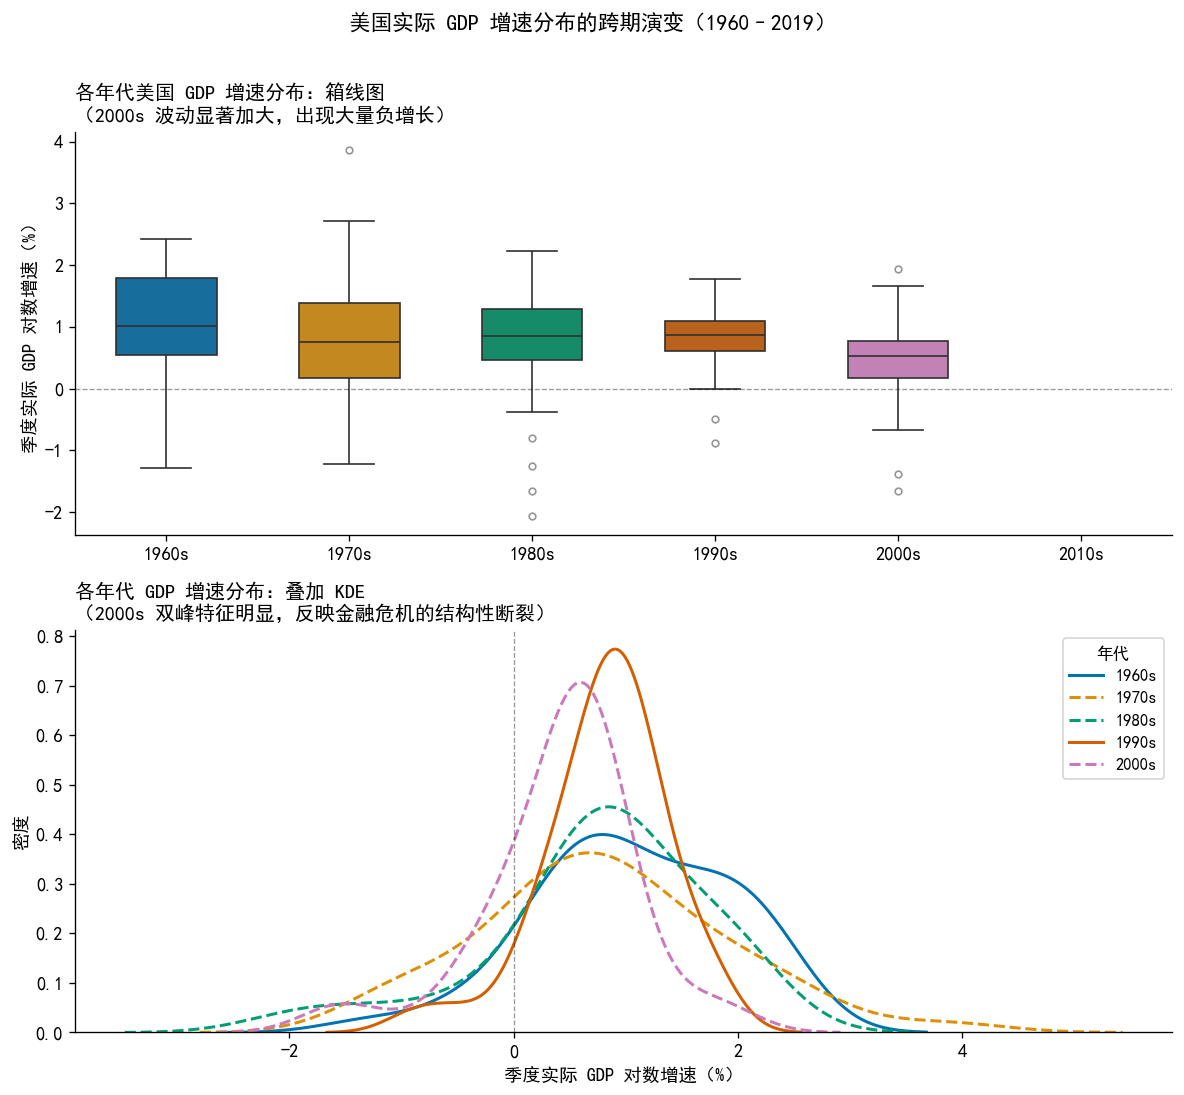

In [19]:
import statsmodels.api as sm

# ── 加载数据 ──────────────────────────────────────────────
macro = sm.datasets.macrodata.load_pandas().data
macro['year'] = macro['year'].astype(int)

# 计算实际 GDP 季度对数增速（%）
macro['gdp_growth'] = np.log(macro['realgdp']).diff() * 100
macro = macro.dropna()

# 按年代分组
def decade_label(year):
    d = (year // 10) * 10
    return f'{d}s'

macro['decade'] = macro['year'].apply(decade_label)
decades_order = ['1960s', '1970s', '1980s', '1990s', '2000s', '2010s']
macro = macro[macro['decade'].isin(decades_order)]

print(f'数据：{macro.year.min()}–{macro.year.max()} 年，共 {len(macro)} 个季度')
print('\n── 各年代 GDP 增速（%）描述统计 ──')
print(macro.groupby('decade')['gdp_growth'].agg(
    均值='mean', 标准差='std', 偏度=stats.skew, 最小值='min', 最大值='max'
).round(3))

# ── 图1：分组箱线图 ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9))

palette = sns.color_palette('colorblind', len(decades_order))
sns.boxplot(data=macro, x='decade', y='gdp_growth',
            order=decades_order, palette=palette,
            width=0.55, ax=ax1,
            flierprops=dict(marker='o', markersize=4, alpha=0.5))
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax1.set_xlabel('')
ax1.set_ylabel('季度实际 GDP 对数增速（%）', fontsize=11)
ax1.set_title('各年代美国 GDP 增速分布：箱线图\n（2000s 波动显著加大，出现大量负增长）',
              fontsize=12, fontweight='bold', loc='left')
sns.despine(ax=ax1)

# ── 图2：叠加 KDE ─────────────────────────────────────────
for decade, color in zip(decades_order, palette):
    subset = macro[macro['decade'] == decade]['gdp_growth']
    ls = '-' if decade in ['1960s', '1990s', '2010s'] else '--'
    sns.kdeplot(subset, ax=ax2, color=color, linewidth=1.8,
                linestyle=ls, label=decade)

ax2.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
ax2.set_xlabel('季度实际 GDP 对数增速（%）', fontsize=11)
ax2.set_ylabel('密度', fontsize=11)
ax2.set_title('各年代 GDP 增速分布：叠加 KDE\n（2000s 双峰特征明显，反映金融危机的结构性断裂）',
              fontsize=12, fontweight='bold', loc='left')
ax2.legend(title='年代', fontsize=10, title_fontsize=10)
sns.despine(ax=ax2)

plt.suptitle('美国实际 GDP 增速分布的跨期演变（1960–2019）',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='sec7'></a>
## 金融收益率的风格化特征诊断

用宏观消费数据模拟金融数据的分布特征诊断流程。

── 美国实际消费季度对数增速（%）描述统计 ──
  均值:      0.8368%
  标准差:    0.6926%
  偏度:      -0.6019  （负偏：极端负值更多）
  超额峰态:  2.0431  （>0：厚尾）
  Jarque-Bera 检验: 统计量=47.33, p值=0.0000
  箱线图离群值: 5 个（2.5%，正态预期约 0.7%）


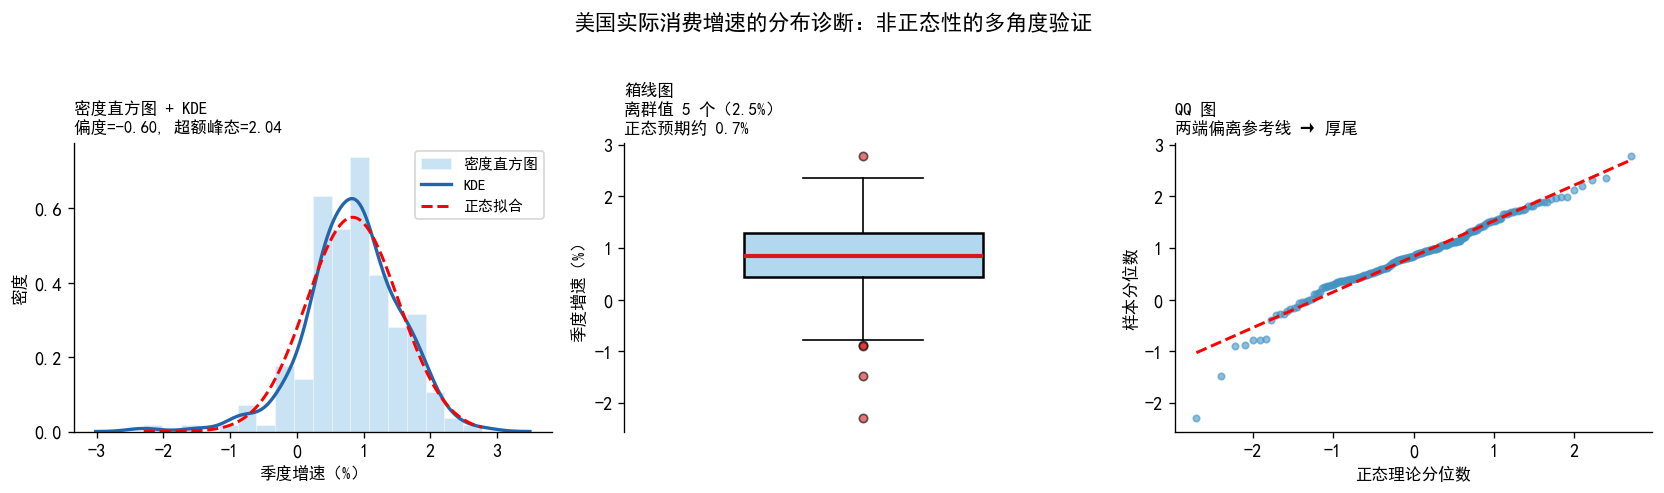


结论：Jarque-Bera 检验 p 值=0.0000，强烈拒绝正态假设


In [20]:
import statsmodels.api as sm

# ── 数据准备 ──────────────────────────────────────────────
macro = sm.datasets.macrodata.load_pandas().data
macro['cons_growth'] = np.log(macro['realcons']).diff() * 100
data = macro['cons_growth'].dropna().values

# ── 描述统计 ─────────────────────────────────────────────
mean_val  = data.mean()
std_val   = data.std()
skew_val  = stats.skew(data)
kurt_val  = stats.kurtosis(data)  # 超额峰态
jb_stat, jb_pval = stats.jarque_bera(data)
n_outliers = np.sum((data < np.percentile(data, 25) - 1.5 * stats.iqr(data)) |
                    (data > np.percentile(data, 75) + 1.5 * stats.iqr(data)))

print('── 美国实际消费季度对数增速（%）描述统计 ──')
print(f'  均值:      {mean_val:.4f}%')
print(f'  标准差:    {std_val:.4f}%')
print(f'  偏度:      {skew_val:.4f}  （负偏：极端负值更多）')
print(f'  超额峰态:  {kurt_val:.4f}  （>0：厚尾）')
print(f'  Jarque-Bera 检验: 统计量={jb_stat:.2f}, p值={jb_pval:.4f}')
print(f'  箱线图离群值: {n_outliers} 个（{n_outliers/len(data)*100:.1f}%，正态预期约 0.7%）')

# ── 三合一诊断图 ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 左：密度直方图 + KDE + 正态曲线
ax = axes[0]
ax.hist(data, bins='fd', density=True, color='#b2d8f0',
        edgecolor='white', linewidth=0.3, alpha=0.7, label='密度直方图')
sns.kdeplot(data, ax=ax, color='#2166ac', linewidth=2, label='KDE')
x_fit = np.linspace(data.min(), data.max(), 300)
ax.plot(x_fit, stats.norm.pdf(x_fit, mean_val, std_val),
        'r--', linewidth=1.8, label='正态拟合')
ax.set_title(f'密度直方图 + KDE\n偏度={skew_val:.2f}, 超额峰态={kurt_val:.2f}',
             fontsize=10, fontweight='bold', loc='left')
ax.set_xlabel('季度增速（%）', fontsize=10)
ax.set_ylabel('密度', fontsize=10)
ax.legend(fontsize=9)
sns.despine(ax=ax)

# 中：箱线图
ax = axes[1]
bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor='#b2d8f0', linewidth=1.5),
                medianprops=dict(color='#d7191c', linewidth=2.5),
                flierprops=dict(marker='o', markersize=5,
                                markerfacecolor='#d7191c', alpha=0.6))
ax.set_xticks([])
ax.set_ylabel('季度增速（%）', fontsize=10)
ax.set_title(f'箱线图\n离群值 {n_outliers} 个（{n_outliers/len(data)*100:.1f}%）\n正态预期约 0.7%',
             fontsize=10, fontweight='bold', loc='left')
sns.despine(ax=ax, bottom=True)

# 右：QQ 图
ax = axes[2]
(theoretical, sample), fit = stats.probplot(data, dist='norm')
ax.scatter(theoretical, sample, color='#4393c3', s=15, alpha=0.6)
x_line = np.array([theoretical.min(), theoretical.max()])
ax.plot(x_line, fit[0] * x_line + fit[1], 'r--', linewidth=1.8)
ax.set_title('QQ 图\n两端偏离参考线 → 厚尾',
             fontsize=10, fontweight='bold', loc='left')
ax.set_xlabel('正态理论分位数', fontsize=10)
ax.set_ylabel('样本分位数', fontsize=10)
sns.despine(ax=ax)

plt.suptitle('美国实际消费增速的分布诊断：非正态性的多角度验证',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n结论：Jarque-Bera 检验 p 值={jb_pval:.4f}，'
      + ('强烈拒绝正态假设' if jb_pval < 0.05 else '不拒绝正态假设'))